In [1]:
from aereo.cache import TaskResultCache
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob

job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_goes19",
)
assets = job.search()

2026-07-08 02:52:49 [info     ] search_called                  provider=search_aws_goes


In [2]:
tasks = job.build_tasks(assets)

2026-07-08 02:52:50 [info     ] build_tasks_start              assets=2 builder=build_grouped_tasks


/root/repos/aereo/.venv/lib/python3.13/site-packages/pydantic/_internal/_validate_call.py:137: UserWarning: assets has no 'crs' column; assuming all assets share the same native CRS. Mixed-CRS assets in one task may fail or produce incorrect results.
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


In [3]:
artifacts = job.execute(
    tasks,
    executor=LocalExecutor(workers=-1, cache=TaskResultCache()),
)
print(f"✓ Extracted {len(artifacts)} artifacts")

2026-07-08 02:52:50 [info     ] execute_start                  executor=LocalExecutor task_count=2
2026-07-08 02:52:56 [debug    ] file_downloaded                engine=satpy local_path=/tmp/aereo_extraction/OR_ABI-L1b-RadF-M6C07_G19_s20260011510229_e20260011519549_c20260011519594.nc
2026-07-08 02:52:56 [debug    ] file_downloaded                engine=satpy local_path=/tmp/aereo_extraction/OR_ABI-L1b-RadF-M6C07_G19_s20260011500229_e20260011509548_c20260011509591.nc
✓ Extracted 8 artifacts


(<Figure size 2000x1732.36 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


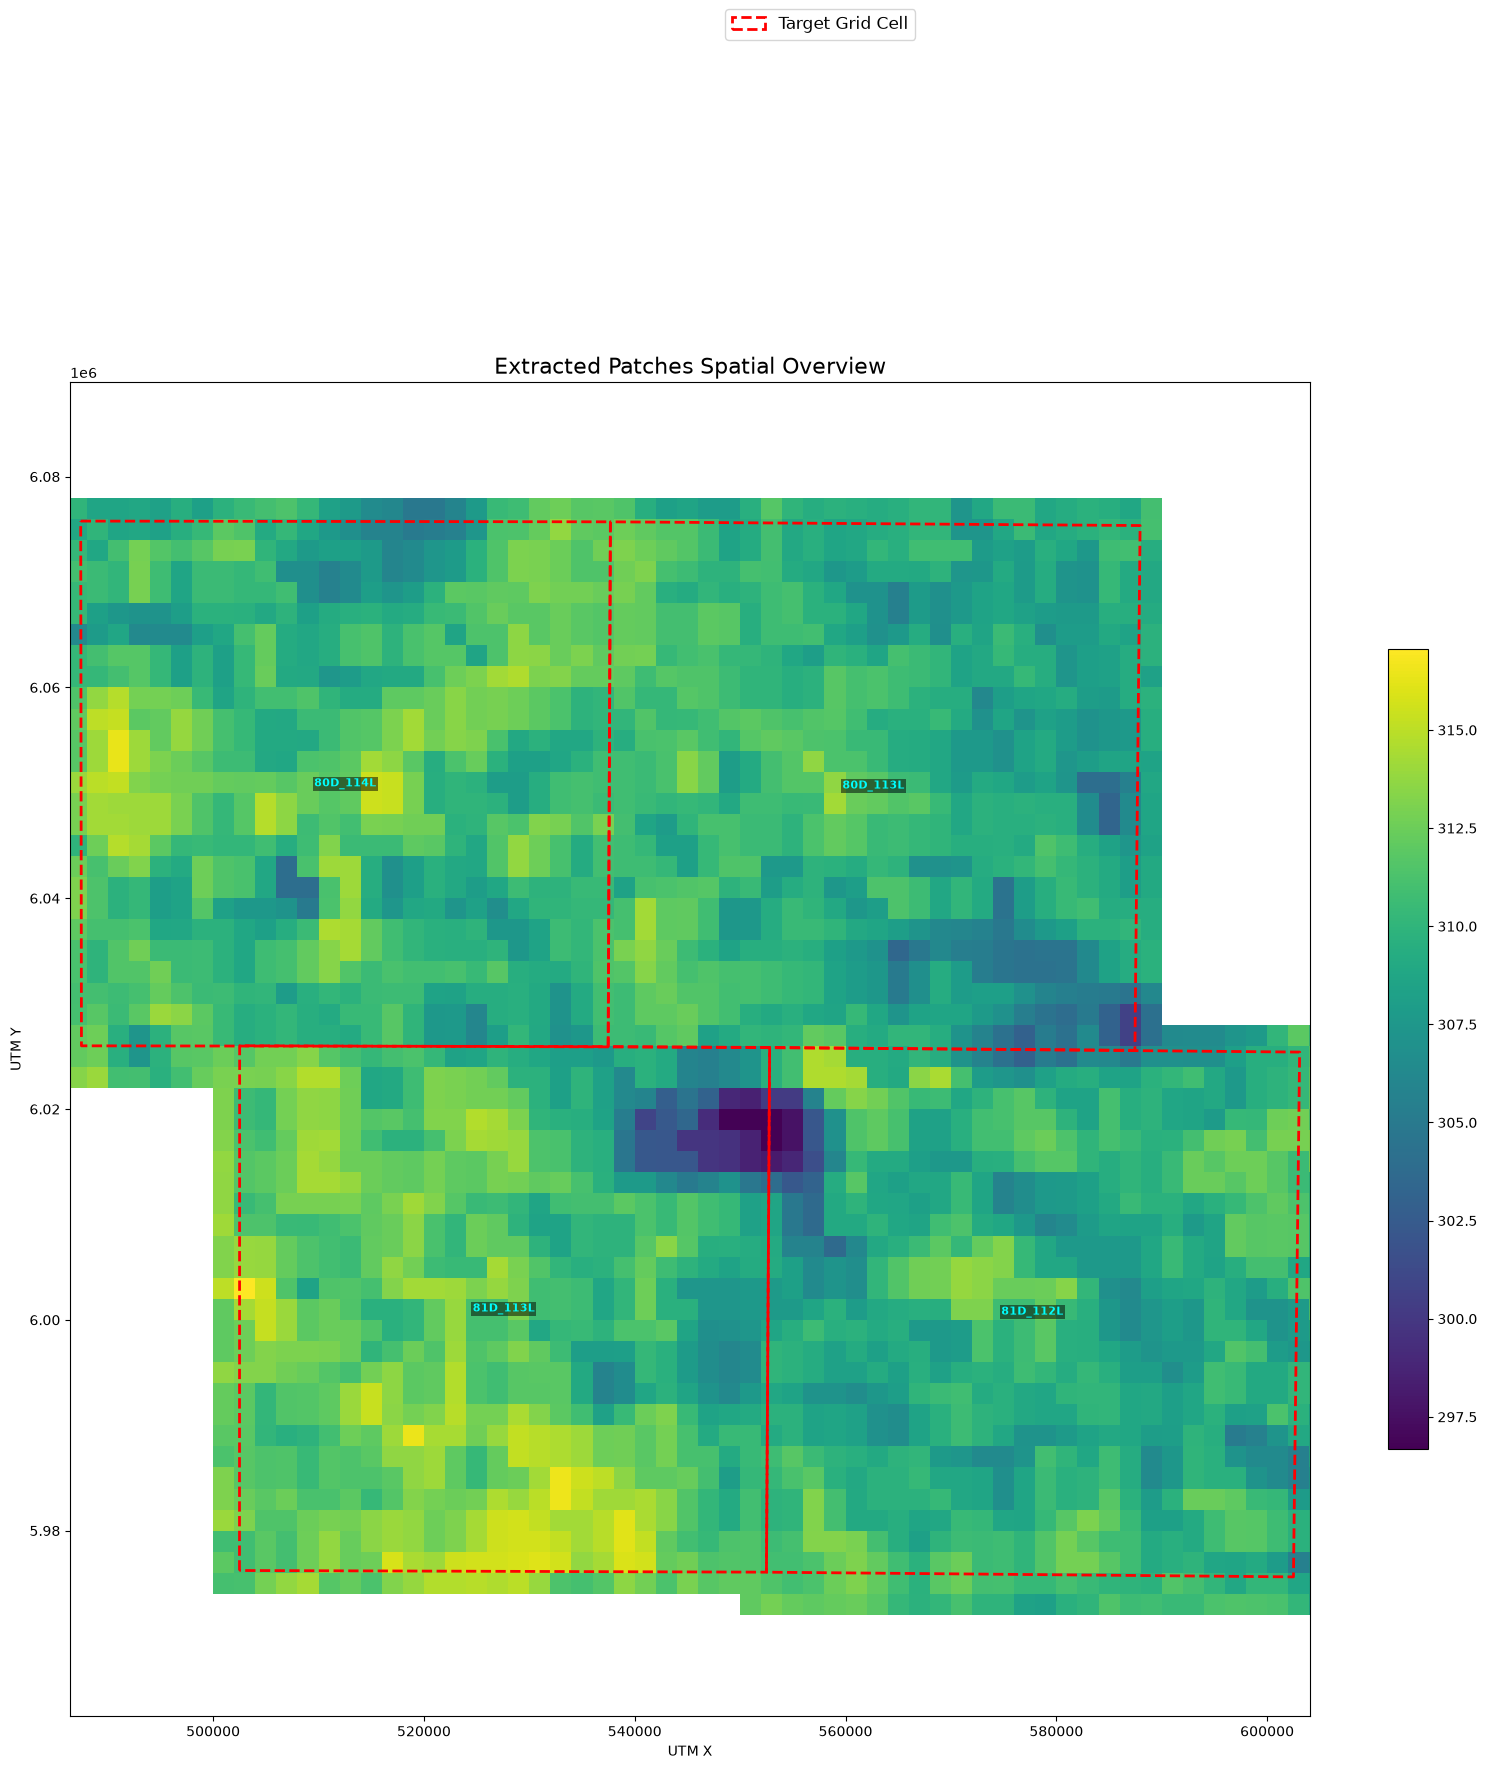

In [5]:
from aereo.viz import plot_artifact_patches

plot_artifact_patches(artifacts, cmap="viridis", ds_factor=1)